
PROJECT 2: DATA CLASSIFICATION USING AI (DecodeLabs - Industrial Training Kit)
================================================================================

AUTHOR: AI Engineering Intern, Batch 2026, Noor R Saad

TOPIC: Supervised Learning - Classification


PROBLEM STATEMENT
================================================================================
Given a set of measurements (sepal length, sepal width, petal length, petal width)
of an Iris flower, predict its species: Setosa, Versicolor, or Virginica.


APPROACH (Supervised Learning Pipeline)
================================================================================
1. LOAD DATA          - Use the classic Iris dataset (150 samples, 4 features, 3 classes)
2. EXPLORE DATA       - Understand shape, statistics, class balance
3. VISUALIZE          - Pairplot, correlation heatmap, feature distributions
4. TRAIN-TEST SPLIT   - 80% training, 20% testing (stratified by default)
5. FEATURE SCALING    - StandardScaler (mean=0, variance=1) - crucial for KNN
6. CHOOSE ALGORITHM   - K-Nearest Neighbors (KNN) with k=5
7. TRAIN MODEL        - model.fit(X_train_scaled, y_train)
8. PREDICT            - model.predict(X_test_scaled)
9. EVALUATE           - Accuracy, Confusion Matrix, Classification Report
10. VISUALIZE RESULTS - Decision boundary (2D projection), Confusion Matrix heatmap
11. TUNE HYPERPARAMETER - Test different k values (1,3,5,7,9,11)


KEY SKILLS DEMONSTRATED
================================================================================
- Data handling with pandas and numpy
- Supervised learning workflow (train/test split, scaling, training, evaluation)
- Using scikit-learn's KNN classifier
- Interpreting confusion matrix and classification metrics (precision, recall, f1-score)
- Visualizing high-dimensional data with matplotlib and seaborn
- Avoiding overfitting by testing on unseen data


FILES GENERATED (Visualizations)
================================================================================
- pairplot.png               : Relationships between all feature pairs colored by species
- correlation_heatmap.png    : Feature correlation matrix
- confusion_matrix.png       : Model's correct/incorrect predictions (heatmap)
- decision_boundary.png      : KNN decision boundary using first two features
- feature_distributions.png  : Histograms + KDE per feature per species


EXPECTED OUTPUT
================================================================================
- Accuracy typically >95% (often 100% for this dataset, but depends on random split)
- Confusion matrix with very few or zero off-diagonal errors
- Classification report with precision/recall/f1-score near 1.00


HOW TO RUN
================================================================================
1. Install required libraries:
   pip install numpy pandas scikit-learn matplotlib seaborn

2. Run the script:
   python project2_classification.py

3. All plots will appear and be saved as PNG files in the current directory.


# **IMPORTS**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Set style for better plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# **LOAD AND PREPARE DATA**

In [3]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Create a DataFrame for easy plotting
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y
df['species_name'] = df['species'].apply(lambda x: target_names[x])

print("DATASET LOADED")
print("=" * 60)
print(f"Samples: {df.shape[0]}, Features: {df.shape[1]-2}")
print(f"Classes: {target_names}")

DATASET LOADED
Samples: 150, Features: 4
Classes: ['setosa' 'versicolor' 'virginica']


# **VISUALIZATION 1 - PAIRPLOT (Relationships between features)**


[Visualization 1] Generating pairplot...


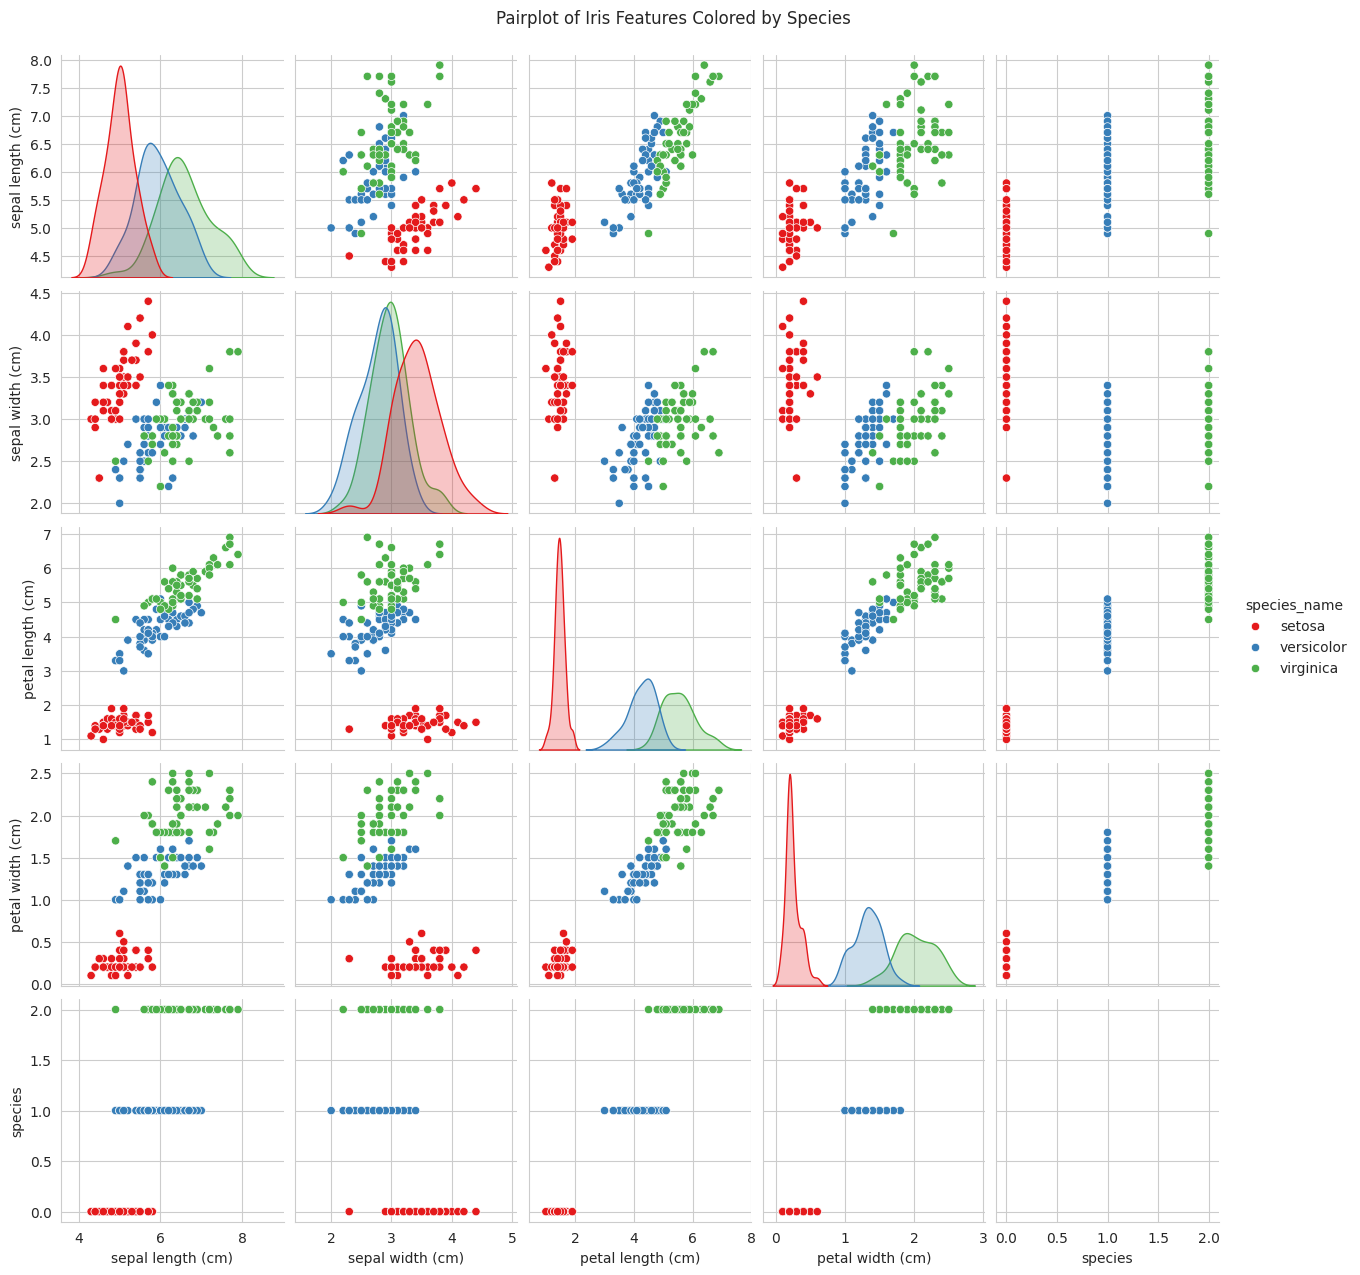

   Saved as: pairplot.png


In [4]:
print("\n[Visualization 1] Generating pairplot...")
sns.pairplot(df, hue='species_name', diag_kind='kde', palette='Set1')
plt.suptitle("Pairplot of Iris Features Colored by Species", y=1.02)
plt.savefig('pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Saved as: pairplot.png")

# **VISUALIZATION 2 - CORRELATION HEATMAP**


[Visualization 2] Generating correlation heatmap...


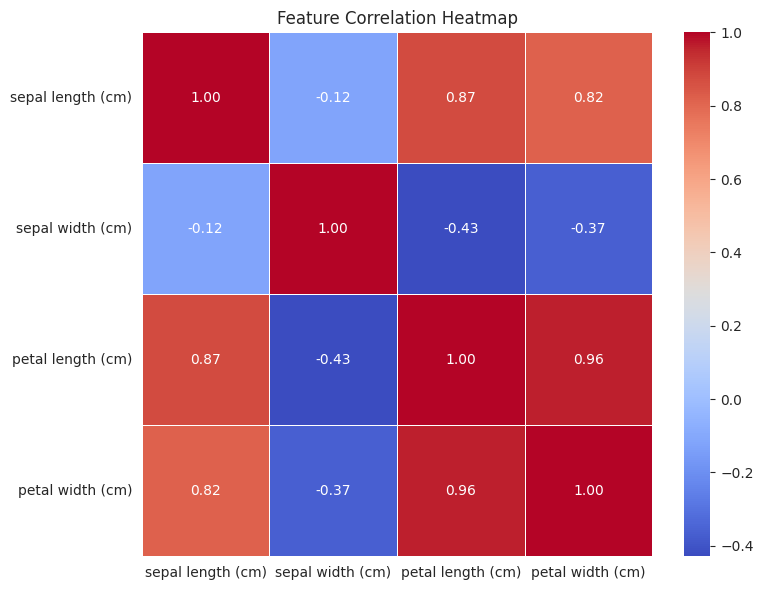

   Saved as: correlation_heatmap.png


In [5]:
print("\n[Visualization 2] Generating correlation heatmap...")
plt.figure(figsize=(8, 6))
corr = df[feature_names].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("   Saved as: correlation_heatmap.png")

# **TRAIN-TEST SPLIT & SCALING**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

# **VISUALIZATION 3 - CONFUSION MATRIX HEATMAP**


[Visualization 3] Generating confusion matrix...


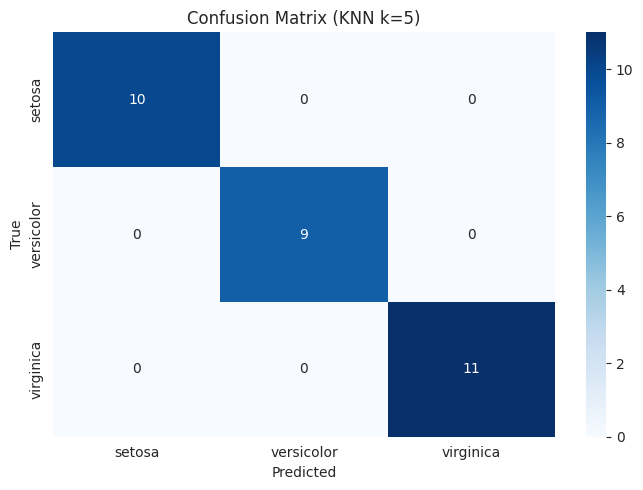

   Saved as: confusion_matrix.png


In [7]:
print("\n[Visualization 3] Generating confusion matrix...")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (KNN k=5)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("   Saved as: confusion_matrix.png")

# **VISUALIZATION 4 - DECISION BOUNDARY (2D projection)**


[Visualization 4] Generating decision boundary (2D projection)...


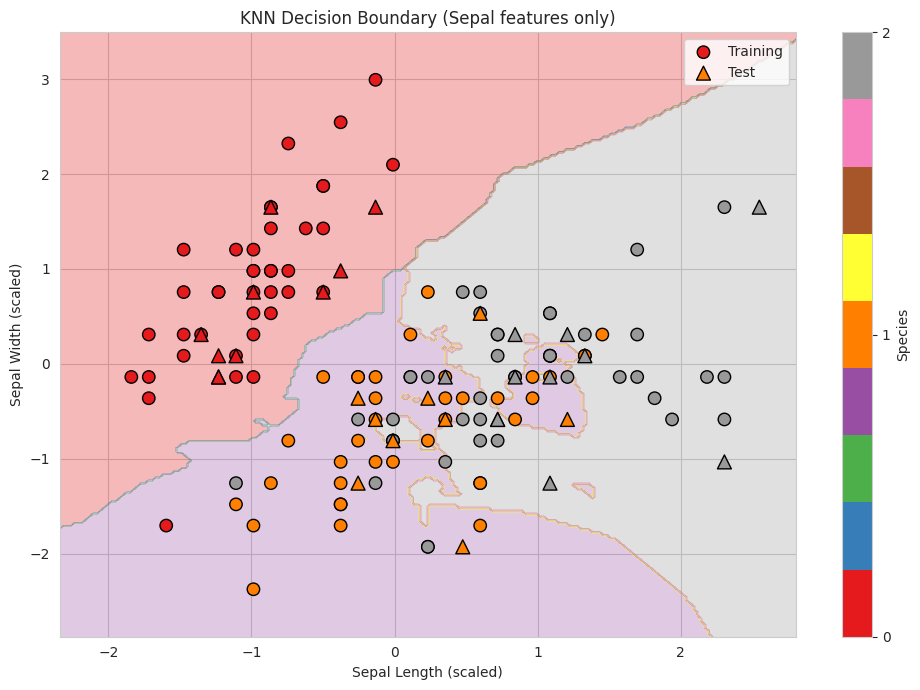

   Saved as: decision_boundary.png


In [8]:
# Use first two features only for visualization (sepal length & width)
print("\n[Visualization 4] Generating decision boundary (2D projection)...")
X_2d = X[:, :2]  # sepal length, sepal width
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.2, random_state=42)

scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

knn_2d = KNeighborsClassifier(n_neighbors=5)
knn_2d.fit(X_train_2d_scaled, y_train_2d)

# Create meshgrid
x_min, x_max = X_train_2d_scaled[:, 0].min() - 0.5, X_train_2d_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_2d_scaled[:, 1].min() - 0.5, X_train_2d_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
# Plot training points
scatter = plt.scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1],
                       c=y_train_2d, cmap='Set1', edgecolor='k', s=80)
plt.scatter(X_test_2d_scaled[:, 0], X_test_2d_scaled[:, 1],
            c=y_test_2d, cmap='Set1', marker='^', edgecolor='k', s=100, label='Test')
plt.xlabel('Sepal Length (scaled)')
plt.ylabel('Sepal Width (scaled)')
plt.title('KNN Decision Boundary (Sepal features only)')
plt.colorbar(scatter, ticks=[0,1,2], label='Species')
plt.legend(['Training', 'Test'], loc='upper right')
plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=150)
plt.show()
print("   Saved as: decision_boundary.png")

# **VISUALIZATION 5 - FEATURE DISTRIBUTION BY SPECIES**


[Visualization 5] Generating feature distributions...


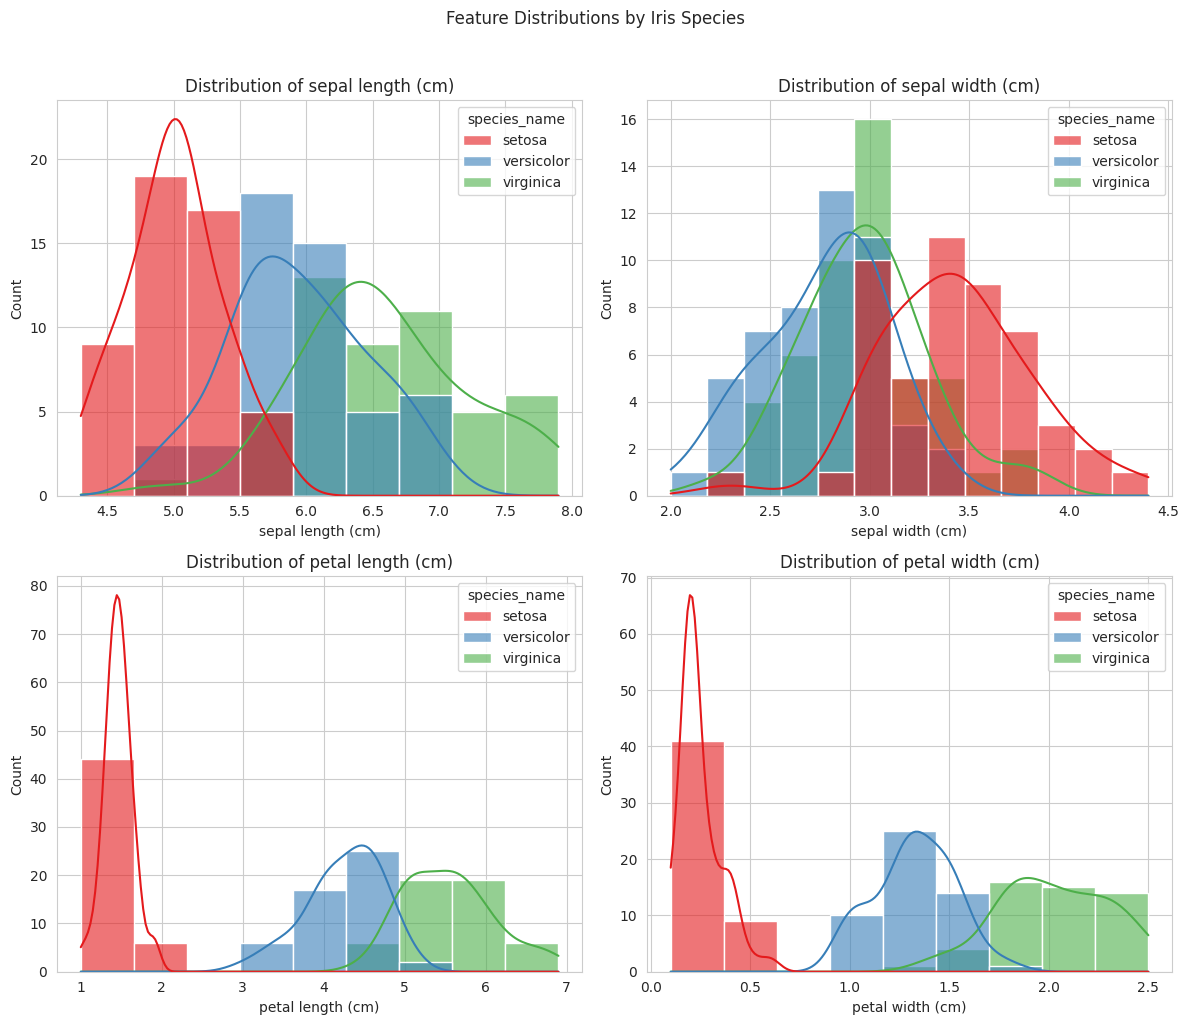

   Saved as: feature_distributions.png


In [9]:
print("\n[Visualization 5] Generating feature distributions...")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, feature in enumerate(feature_names):
    sns.histplot(data=df, x=feature, hue='species_name', kde=True,
                 ax=axes[idx], palette='Set1', alpha=0.6)
    axes[idx].set_title(f'Distribution of {feature}')

plt.suptitle('Feature Distributions by Iris Species', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()
print("   Saved as: feature_distributions.png")

# **PRINT ACCURACY**

In [10]:
accuracy = accuracy_score(y_test, y_pred)
print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


MODEL EVALUATION
Accuracy: 1.0000 (100.00%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

